In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import os
import requests
from tqdm import tqdm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from itertools import product
import socket

from DATA.stock_invest_function import *
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

In [2]:
matplotlib.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

In [3]:
# 날짜를 회계분기 말일로 정규화
def normalize_dates_to_quarter_end(df):
    df = df.copy()
    df = df.reset_index()
    df['date'] = pd.to_datetime(df['date']) + pd.offsets.QuarterEnd(0)
    df = df.set_index('date')
    return df

def get_db_host():
    try:
        # 현재 로컬 IP 주소 확인
        local_ip = socket.gethostbyname(socket.gethostname())

        # 내부 네트워크면 192로 시작 (또는 10. / 172.16~31 도 가능)
        if local_ip.startswith("192.168."):
            return '192.168.0.230'  # 집 내부 IP로 수정
        else:
            return 'hystox74.synology.me'  # 외부 접속용 DDNS 주소
    except Exception as e:
        print("⚠️ IP 확인 실패:", e)
        return 'hystox74.synology.me'  # 예외 발생 시 외부 주소 사용

# long-format 변환 함수 (ticker는 컬럼에서 제거하고 별도 컬럼으로 분리)
def reshape_FMP_data(margin_df):
    melted_df = margin_df.reset_index().melt(id_vars=['date', 'ticker'], var_name='accounting_item', value_name='value')
    final_df = melted_df.dropna().sort_values(['accounting_item', 'ticker', 'date'])
    return final_df

# 마진 및 성장률 시계열 데이터 수집 및 long-format 변환
def get_FMP_data(ticker_list, apikey):
    result_df_list = []

    for ticker in tqdm(ticker_list, desc="Fetching income statements"):
        url = f"https://financialmodelingprep.com/api/v3/income-statement/{ticker}?period=quarter&limit=100&apikey={apikey}"
        response = requests.get(url)
        if response.status_code != 200:
            print(f"❌ {ticker} API 요청 실패: {response.status_code}")
            continue

        data = response.json()
        df = pd.DataFrame(data)
        if df.empty:
            print(f"❌ {ticker} 수신 데이터 없음.")
            continue

        df['date'] = pd.to_datetime(df['date'])
        df.set_index('date', inplace=True)
        df.sort_index(inplace=True)

        # 기본 컬럼 정의
        df['revenue'] = df['revenue']
        df['grossProfit'] = df['grossProfit']
        df['operatingIncome'] = df['operatingIncome']
        df['netIncome'] = df['netIncome']

        # 마진율 계산
        df['GPM'] = df['grossProfit'] / df['revenue']
        df['OPM'] = df['operatingIncome'] / df['revenue']
        df['NPM'] = df['netIncome'] / df['revenue']

        # 성장률 계산
        for col in ['revenue', 'grossProfit', 'operatingIncome', 'netIncome']:
            df[f'{col}_qoq'] = df[col].pct_change(periods=1)
            df[f'{col}_yoy'] = df[col].pct_change(periods=4)

        # 필요한 항목만 추출
        keep_cols = ['revenue', 'grossProfit', 'operatingIncome', 'netIncome',
                     'GPM', 'OPM', 'NPM',
                     'revenue_qoq', 'grossProfit_qoq', 'operatingIncome_qoq', 'netIncome_qoq',
                     'revenue_yoy', 'grossProfit_yoy', 'operatingIncome_yoy', 'netIncome_yoy']

        sub_df = df[keep_cols]
        sub_df = normalize_dates_to_quarter_end(sub_df)
        sub_df['ticker'] = ticker

        result_df_list.append(sub_df)

    # 전체 병합 및 정렬
    if not result_df_list:
        return pd.DataFrame()

    full_df = pd.concat(result_df_list)
    full_df = full_df.replace([np.inf, -np.inf], np.nan)
    full_df = full_df.sort_index()

    return full_df

def merge_wrds_and_fmp(endog_df, fmp_df, tic_name):
    """
    endog_df를 우선으로 사용하고, 값이 없는 경우에만 fmp_df의 값을 채워넣습니다.

    Parameters:
        - endog_df: 주된 데이터프레임
        - fmp_df: 보조 데이터프레임
        - tic_name: 병합 대상인 칼럼 이름 (ex: 'COHR')

    Returns:
        - 병합된 DataFrame (date, tic_name)
    """
    # 1. 날짜를 분기 종료일로 통일
    for df in [endog_df, fmp_df]:
        df['date'] = pd.to_datetime(df['date']).dt.to_period("Q").dt.to_timestamp(how='end').dt.normalize()

    # 2. 날짜 기준으로 outer merge
    merged = pd.merge(
        endog_df[['date', tic_name]],
        fmp_df[['date', tic_name]].rename(columns={tic_name: 'fmp_value'}),
        on='date',
        how='outer'
    ).sort_values('date')

    # 3. 메인 데이터 우선, 보조 데이터 보완
    merged['final'] = merged[tic_name].combine_first(merged['fmp_value'])

    # 4. 정리: date, 최종값만 반환
    result = merged[['date', 'final']].rename(columns={'final': tic_name})
    return result

def merge_endog_exog_data(endog_df, exog_df,
                          endog_col, exog_col,
                          start_date=None, end_date=None):
    """
    두 데이터프레임에서 지정한 칼럼을 추출하고 날짜 기준으로 병합합니다.
    """

    # 1. 복사 및 날짜 처리
    endog_df = endog_df.copy()
    exog_df = exog_df.copy()

    # 날짜 → 분기 종료일 → 시간 정보 제거
    # 날짜 → 분기 종료일 → 시간 제거
    endog_df['date'] = pd.to_datetime(endog_df['date']).dt.to_period('Q').dt.to_timestamp(how='end').dt.normalize()
    exog_df['date'] = pd.to_datetime(exog_df['date']).dt.to_period('Q').dt.to_timestamp(how='end').dt.normalize()

    # 2. 외생변수는 중복 제거
    exog_df = exog_df.groupby('date')[exog_col].last().reset_index()

    # 3. 날짜 필터링
    if start_date:
        start = pd.to_datetime(start_date)
        endog_df = endog_df[endog_df['date'] >= start]
        exog_df = exog_df[exog_df['date'] >= start]
    if end_date:
        end = pd.to_datetime(end_date)
        endog_df = endog_df[endog_df['date'] <= end]
        exog_df = exog_df[exog_df['date'] <= end]

    # 4. 필요한 칼럼 추출
    endog_df = endog_df[['date', endog_col]]
    exog_df = exog_df[['date', exog_col]]

    # 5. 병합
    merged_df = pd.merge(endog_df, exog_df, on='date', how='inner')

    # 6. 열 이름 변경
    merged_df.rename(columns={
        endog_col: 'endog_var',
        exog_col: 'exog_var'
    }, inplace=True)

    return merged_df

def forecast_future_4q_with_sarima(df, date_col='date', value_col='endog_var', exog_col=None,
                                   use_log=True, fixed_variable=0):
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    from statsmodels.stats.diagnostic import acorr_ljungbox
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    import matplotlib.pyplot as plt
    from itertools import product
    import numpy as np
    from tqdm import tqdm
    import pandas as pd

    # 시계열 설정
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.set_index(date_col).asfreq('Q')
    ts = df[value_col]

    # 로그 변환을 먼저 적용
    if use_log:
        ts_transformed = np.log(ts)
        print("✅ 로그 변환 적용")
    else:
        ts_transformed = ts

    # 외생변수 설정 (ts_transformed 이후에 실행되어야 함)
    if exog_col:
        exog = df[exog_col]
        exog_train = exog.loc[ts_transformed.index]   # ✅ 이제 안전하게 접근 가능
        exog_forecast = exog.iloc[-4:]
        print(f"📎 외생변수 '{exog_col}' 포함")
    else:
        exog_train = exog_forecast = None

    # 로그 변환
    if use_log:
        ts_transformed = np.log(ts)
        print("✅ 로그 변환 적용")
    else:
        ts_transformed = ts

    # SARIMA 학습
    if fixed_variable == 1:
        order = (1, 1, 1)
        seasonal_order = (1, 1, 1, 4)
        print(f"🔧 고정 SARIMA 구조 사용: order={order}, seasonal_order={seasonal_order}")
        model = SARIMAX(ts_transformed, order=order, seasonal_order=seasonal_order,
                        exog=exog if exog_col else None)
        result = model.fit(disp=False)
    else:
        p = d = q = P = D = Q = [0, 1]
        s = 4
        best_aic = np.inf
        best_model = None
        print(f"🔍 Grid Search 진행 중...")

        for order in product(p, d, q):
            for seasonal in product(P, D, Q):
                seasonal_order = (*seasonal, s)
                try:
                    model = SARIMAX(ts_transformed, order=order,
                                    seasonal_order=seasonal_order,
                                    exog=exog_train if exog_col else None)
                    temp_result = model.fit(disp=False)
                    if temp_result.aic < best_aic:
                        best_aic = temp_result.aic
                        best_model = temp_result
                        best_order = order
                        best_seasonal = seasonal_order
                except Exception as e:
                    print(f"⚠️ 실패: order={order}, seasonal={seasonal_order}, error={e}")
                    continue

        if best_model is None:
            print("❌ Grid Search 실패: 유효한 SARIMA 모형이 하나도 학습되지 않았습니다.")
            return None

        result = best_model
        print(f"✅ 최적 모형: order={best_order}, seasonal_order={best_seasonal}, AIC={best_aic:.2f}")

    # 예측
    forecast_log = result.forecast(steps=4, exog=exog_forecast if exog_col else None)
    forecast = np.exp(forecast_log) if use_log else forecast_log

    # fittedvalues → 원 단위로 변환
    fitted = result.fittedvalues
    fitted = np.exp(fitted) if use_log else fitted

    # 실제값과 fitted값 align
    ts_valid = ts[fitted.index]  # 잘린 부분 제외
    residuals_original = ts_valid - fitted

    # 예측 시각화
    plt.figure(figsize=(12, 5))
    plt.plot(ts.index, ts.values, label='실제 시계열', color='skyblue')
    plt.plot(forecast.index, forecast.values, label='예측값 (미래 4분기)', linestyle='--', marker='o', color='orange')
    plt.xlim(ts.index.min(), forecast.index.max())
    y_min = min(ts.min(), forecast.min()) * 0.95
    y_max = max(ts.max(), forecast.max()) * 1.05
    plt.ylim(y_min, y_max)
    plt.title("전체 데이터 및 SARIMA 예측 결과", fontsize=14)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("\n📈 미래 4분기 예측 결과:")
    print(forecast)

    # 잔차 진단 (원 단위 residual)
    print("\n📊 Ljung-Box Test (잔차 자기상관):")
    print(acorr_ljungbox(residuals_original.dropna(), lags=[4, 8, 12], return_df=True))

    plt.figure(figsize=(12, 6))
    plt.subplot(2, 2, 1)
    plt.plot(residuals_original)
    plt.title("잔차 시계열 (원 단위)")

    plt.subplot(2, 2, 2)
    plot_acf(residuals_original.dropna(), ax=plt.gca(), lags=20)
    plt.title("잔차 ACF")

    plt.subplot(2, 2, 3)
    plot_pacf(residuals_original.dropna(), ax=plt.gca(), lags=20)
    plt.title("잔차 PACF")

    plt.subplot(2, 2, 4)
    plt.hist(residuals_original.dropna(), bins=20)
    plt.title("잔차 분포")

    plt.tight_layout()
    plt.show()

    return forecast

In [4]:

save_path = r"C:\Users\MetaM\PycharmProjects\stock_forecast\DATA"

tic_name = 'ANET'
hs_code = '851762'
item_name = 'PSR'

st_date = '2010-01-01'
end_date = '2025-03-31'
apikey = 'hT0gAk87j9xZx4PlBApvBqfVL5IahvgV'

db_info = {
    'host' : get_db_host(),
    'port' : 3307,
    'user' : 'stox7412',
    'password' : 'Apt106503!~',
    'database' : 'investar'
}

# 전자담배 장치 (전자기기 형태의 흡연기기 포함)

#### 1. 데이터 수집 (DB 데이터 Call)

In [5]:
## 미국 기업 재무정보
fundq_df = fetch_table_data(db_info, 'US_fundq')

## 미국 수출 데이터
trade_df = fetch_table_data(db_info, 'us_trade_monthly_data_with_forecast')

tickers = [tic_name]
wide_df = get_FMP_data(tickers, apikey)
long_df = reshape_FMP_data(wide_df)

accounting_name = 'revenue'
FMP_df = long_df[(long_df['ticker'] == tic_name) & (long_df['accounting_item'] == accounting_name)][['date', 'value']].copy()
FMP_df.rename(columns={'value': tic_name}, inplace=True)

✅ 'US_fundq' 테이블에서 1572228건의 데이터를 가져왔습니다.
✅ 'us_trade_monthly_data_with_forecast' 테이블에서 14639건의 데이터를 가져왔습니다.


Fetching income statements: 100%|██████████| 1/1 [00:01<00:00,  1.02s/it]


In [10]:
endog_df = fundq_df[fundq_df['ticker'] == tic_name][['date', 'saleq']]
endog_df.rename(columns={'saleq' : tic_name}, inplace=True)
endog_month_df = fundq_df[fundq_df['ticker'] == tic_name][['date', 'saleq']]
endog_month_df.rename(columns={'saleq' : tic_name}, inplace=True)

# 날짜 처리 및 분기당 마지막 날짜만 추출
endog_df['date'] = pd.to_datetime(endog_df['date'])
endog_df['quarter'] = endog_df['date'].dt.to_period('Q')
endog_df = endog_df.sort_values('date').groupby('quarter').last().reset_index(drop=True)
endog_df = endog_df[(endog_df['date'] >= st_date) & (endog_df['date'] <= end_date)]

In [11]:
temp_df = trade_df[trade_df['hs_code_6d'] == hs_code][['date','expDlr']]

# 중복 제거
target_export_df = temp_df.drop_duplicates(subset=['date'])

# date를 datetime으로 변환
target_export_df['date'] = pd.to_datetime(target_export_df['date'])

# 분기 추출 및 그룹화
target_export_df['quarter'] = target_export_df['date'].dt.to_period('Q')
quarterly_sum_df = target_export_df.groupby('quarter')['expDlr'].sum().reset_index()

# datetime 변환 후 추가 계산
quarterly_sum_df['quarter'] = quarterly_sum_df['quarter'].dt.to_timestamp()
quarterly_sum_df['export_qoq_change'] = quarterly_sum_df['expDlr'].pct_change(periods=1)
quarterly_sum_df['export_yoy_change'] = quarterly_sum_df['expDlr'].pct_change(periods=4)
quarterly_sum_df['date_month'] = quarterly_sum_df['quarter'] + pd.offsets.QuarterEnd(0)
quarterly_sum_df['date'] = pd.to_datetime(quarterly_sum_df['date_month'])

# date를 인덱스로 설정
quarterly_sum_df.set_index('date', inplace=True)
# ✅ (선택적으로 quarter 컬럼 제거)
quarterly_sum_df.drop(columns='quarter', inplace=True)

quarterly_sum_df = quarterly_sum_df.reset_index()

## nan value  제거
quarterly_sum_df = quarterly_sum_df.iloc[8:]
# 💡 로그변환 제거 → 원시 endog_var 사용
# 💡 외생 변수 exog_var는 표준화(Z-score) 적용
scaler = StandardScaler()
quarterly_sum_df['exog_scaled'] = scaler.fit_transform(quarterly_sum_df[['export_yoy_change']])


In [12]:
merged = merge_endog_exog_data(
    endog_df = endog_df,
    exog_df = quarterly_sum_df,
    endog_col=tic_name,
    exog_col='export_yoy_change',
    start_date= st_date,
    end_date= end_date
)
merged = merged.drop_duplicates(subset=['date', 'endog_var'], keep='first').reset_index()

✅ 로그 변환 적용
📎 외생변수 'exog_var' 포함
✅ 로그 변환 적용
🔍 Grid Search 진행 중...
✅ 최적 모형: order=(1, 1, 0), seasonal_order=(1, 0, 0, 4), AIC=-100.46


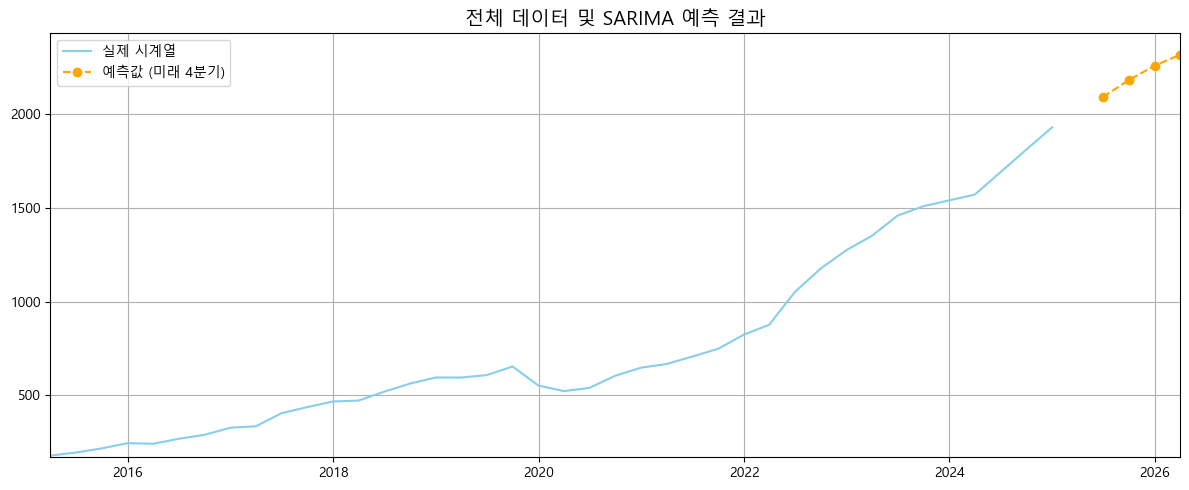


📈 미래 4분기 예측 결과:
2025-06-30    2092.249000
2025-09-30    2182.290847
2025-12-31    2259.164459
2026-03-31    2317.797444
Freq: Q-DEC, Name: predicted_mean, dtype: float64

📊 Ljung-Box Test (잔차 자기상관):
     lb_stat  lb_pvalue
4   3.157591   0.531808
8   3.373453   0.908786
12  9.743141   0.638483


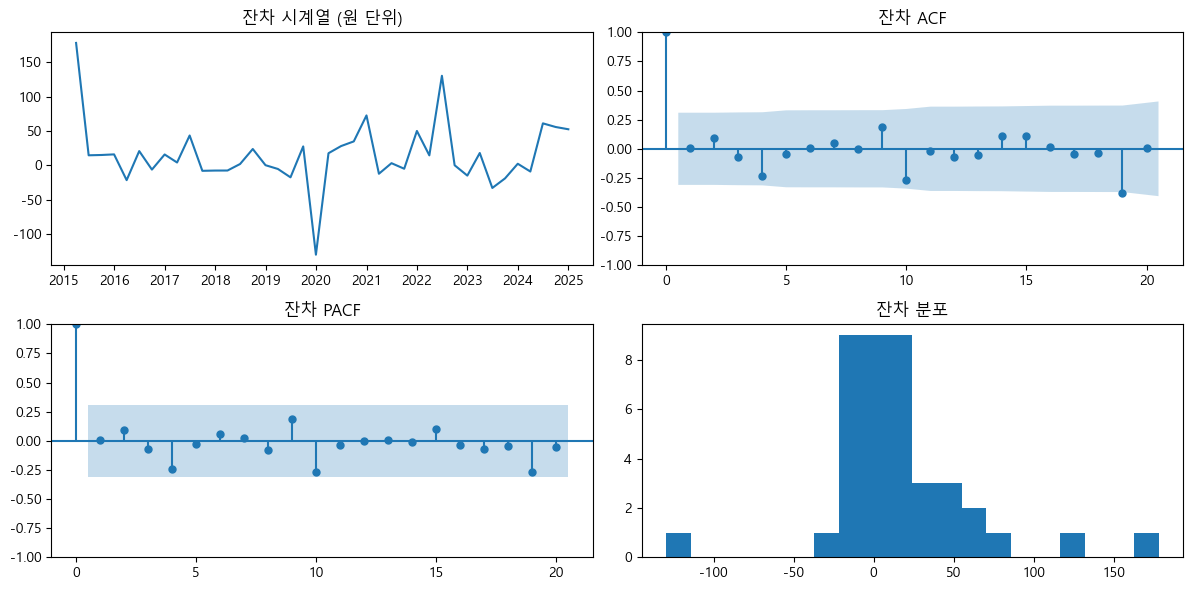

2025-06-30    2092.249000
2025-09-30    2182.290847
2025-12-31    2259.164459
2026-03-31    2317.797444
Freq: Q-DEC, Name: predicted_mean, dtype: float64

In [13]:
forecast_future_4q_with_sarima(merged, value_col='endog_var', exog_col='exog_var', fixed_variable=0)

✅ 로그 변환 적용
✅ 로그 변환 적용
🔍 Grid Search 진행 중...
✅ 최적 모형: order=(1, 1, 1), seasonal_order=(1, 0, 1, 4), AIC=-102.27


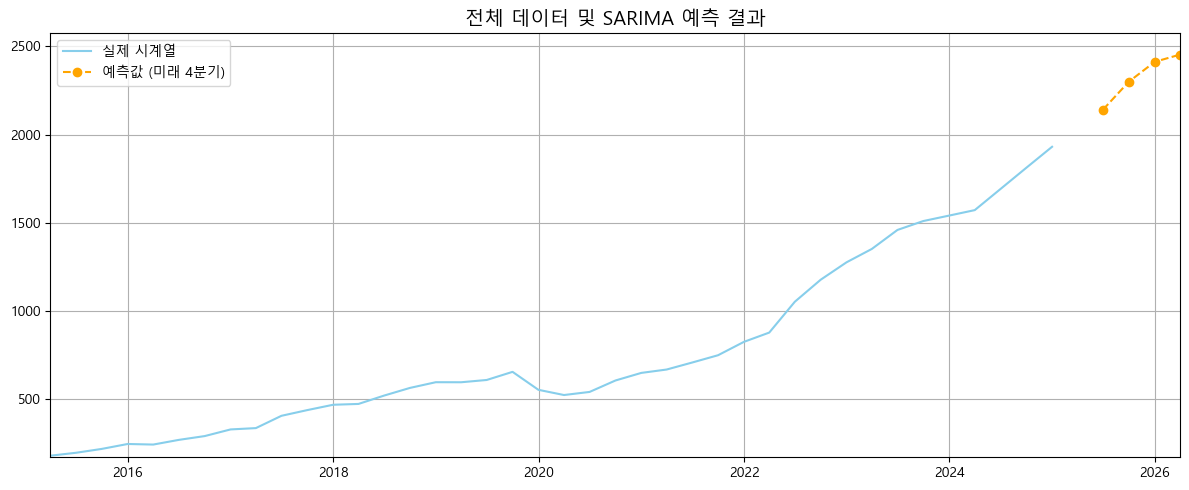


📈 미래 4분기 예측 결과:
2025-06-30    2140.820530
2025-09-30    2299.335995
2025-12-31    2411.931087
2026-03-31    2453.114738
Freq: Q-DEC, Name: predicted_mean, dtype: float64

📊 Ljung-Box Test (잔차 자기상관):
     lb_stat  lb_pvalue
4   1.242265   0.871092
8   2.443851   0.964298
12  8.023101   0.783323


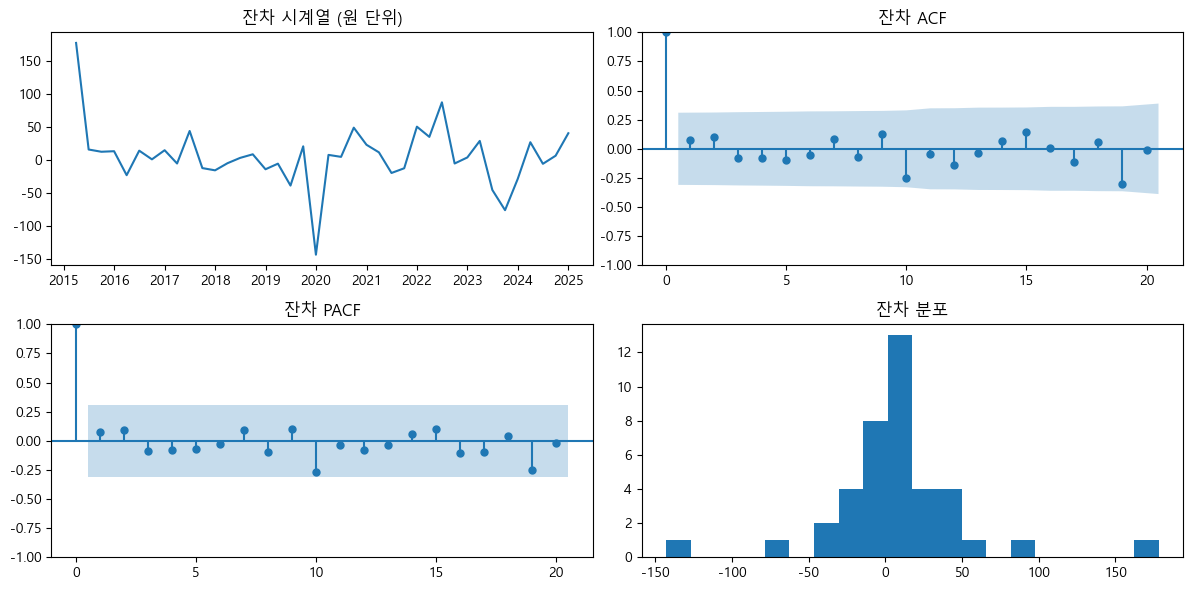

2025-06-30    2140.820530
2025-09-30    2299.335995
2025-12-31    2411.931087
2026-03-31    2453.114738
Freq: Q-DEC, Name: predicted_mean, dtype: float64

In [14]:
 # 외생변수 포함, 로그 사용, 고정 파라미터로 실행
forecast_future_4q_with_sarima(merged, value_col='endog_var', exog_col= None, fixed_variable=0)

In [15]:
# 🔁 결과 저장용 리스트
ratios_timeseries = []

for ticker in tqdm(tickers):
    try:
        url = f"https://financialmodelingprep.com/api/v3/ratios/{ticker}?period=quarter&limit=1000&apikey={apikey}"
        response = requests.get(url)
        data = response.json()

        if isinstance(data, list):
            for entry in data:
                ratios_timeseries.append({
                    'ticker': ticker,
                    'date': entry.get('date'),
                    'PER': entry.get('priceEarningsRatio'),
                    'PBR': entry.get('priceToBookRatio'),
                    'PSR': entry.get('priceToSalesRatio'),
                    'ROE': entry.get('returnOnEquity'),
                    'ROA': entry.get('returnOnAssets'),
                    'DividendPayout': entry.get('payoutRatio')
                })
        else:
            print(f"[⚠️ 없음] {ticker}: 데이터 구조가 예상과 다름")

    except Exception as e:
        print(f"[❌ 오류] {ticker}: {e}")

# 📊 DataFrame으로 변환 및 정렬
df_ratios = pd.DataFrame(ratios_timeseries)
df_ratios.sort_values(by=['ticker', 'date'], inplace=True)

endog_ratio_df = df_ratios[(df_ratios['ticker'] == tic_name)][['date', 'PSR']].copy()

# ✅ Step 1: 날짜 형식 변환
endog_ratio_df['date'] = pd.to_datetime(endog_ratio_df['date'])

# ✅ Step 2: 월 기준으로 분기 판단
def get_standard_quarter(month):
    if month in [1, 2, 3]:
        return 'Q1'
    elif month in [4, 5, 6]:
        return 'Q2'
    elif month in [7, 8, 9]:
        return 'Q3'
    elif month in [10, 11, 12]:
        return 'Q4'
    else:
        return None

# ✅ Step 3: 분기에 따른 일반 분기 종료일 매핑
def get_quarter_end_date(row):
    year = row['date'].year
    quarter = row['quarter']
    if quarter == 'Q1':
        return pd.Timestamp(year=year, month=3, day=31)
    elif quarter == 'Q2':
        return pd.Timestamp(year=year, month=6, day=30)
    elif quarter == 'Q3':
        return pd.Timestamp(year=year, month=9, day=30)
    elif quarter == 'Q4':
        return pd.Timestamp(year=year, month=12, day=31)
    else:
        return pd.NaT

# ✅ Step 4: 파생 변수 추가
endog_ratio_df['quarter'] = endog_ratio_df['date'].dt.month.apply(get_standard_quarter)
endog_ratio_df['aligned_date'] = endog_ratio_df.apply(get_quarter_end_date, axis=1)

# 기존 'date' 칼럼 제거
endog_ratio_df.drop(columns=['date'], inplace=True)
# 'aligned_date' 칼럼을 'date'로 이름 변경
endog_ratio_df.rename(columns={'aligned_date': 'date'}, inplace=True)

merged_ratio_exog = pd.merge(endog_ratio_df, quarterly_sum_df, on = 'date', how = 'left')
merged_ratio_exog = merged_ratio_exog[(merged_ratio_exog['date'] >= '2015-01-01') & (merged_ratio_exog['date'] <= '2026-06')][['date', item_name, 'exog_scaled']].copy()
merged_ratio_exog.rename(columns={item_name : 'endog_var', 'exog_scaled' : 'exog_var'}, inplace=True)

100%|██████████| 1/1 [00:01<00:00,  1.04s/it]


📎 외생변수 'exog_var' 포함
🔍 Grid Search 진행 중...
✅ 최적 모형: order=(0, 1, 0), seasonal_order=(0, 1, 1, 4), AIC=264.68


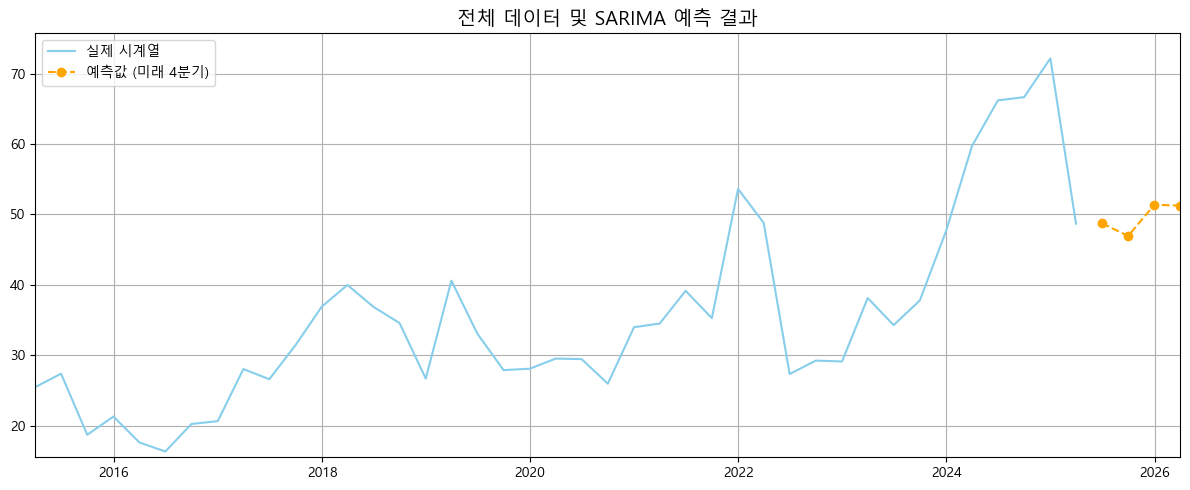


📈 미래 4분기 예측 결과:
2025-06-30    48.743129
2025-09-30    46.946294
2025-12-31    51.374276
2026-03-31    51.256358
Freq: Q-DEC, Name: predicted_mean, dtype: float64

📊 Ljung-Box Test (잔차 자기상관):
      lb_stat  lb_pvalue
4    3.216566   0.522259
8    4.420430   0.817340
12  10.267060   0.592544


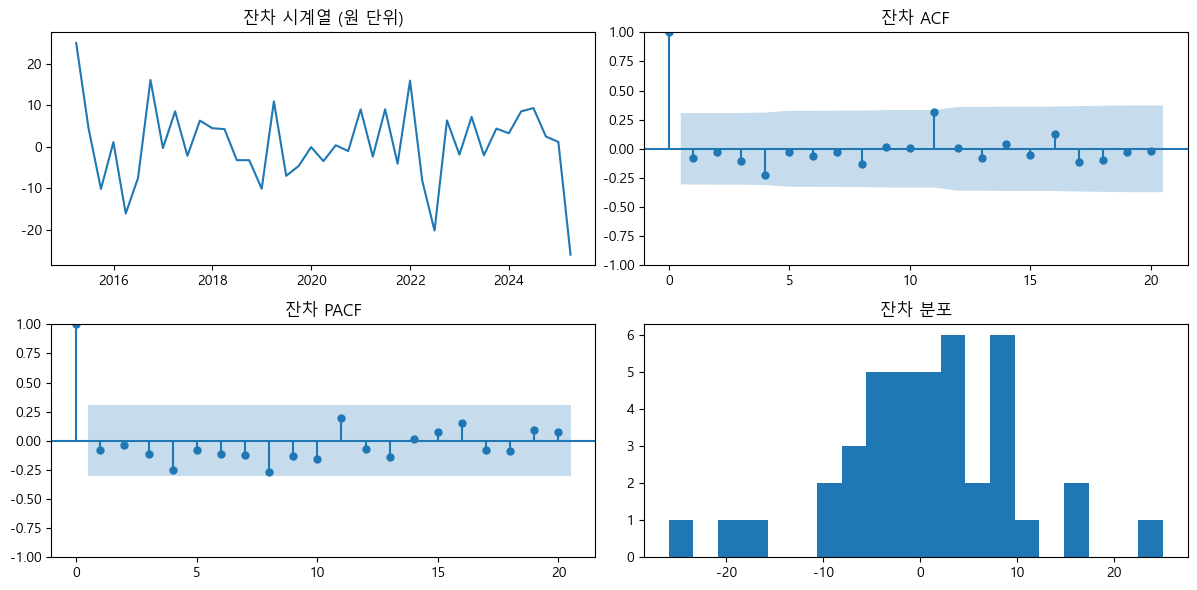

2025-06-30    48.743129
2025-09-30    46.946294
2025-12-31    51.374276
2026-03-31    51.256358
Freq: Q-DEC, Name: predicted_mean, dtype: float64

In [16]:
forecast_future_4q_with_sarima(merged_ratio_exog, value_col='endog_var', exog_col='exog_var', use_log= False, fixed_variable=0)

📎 외생변수 'exog_var' 포함
🔍 Grid Search 진행 중...
✅ 최적 모형: order=(0, 1, 0), seasonal_order=(0, 1, 1, 4), AIC=264.68


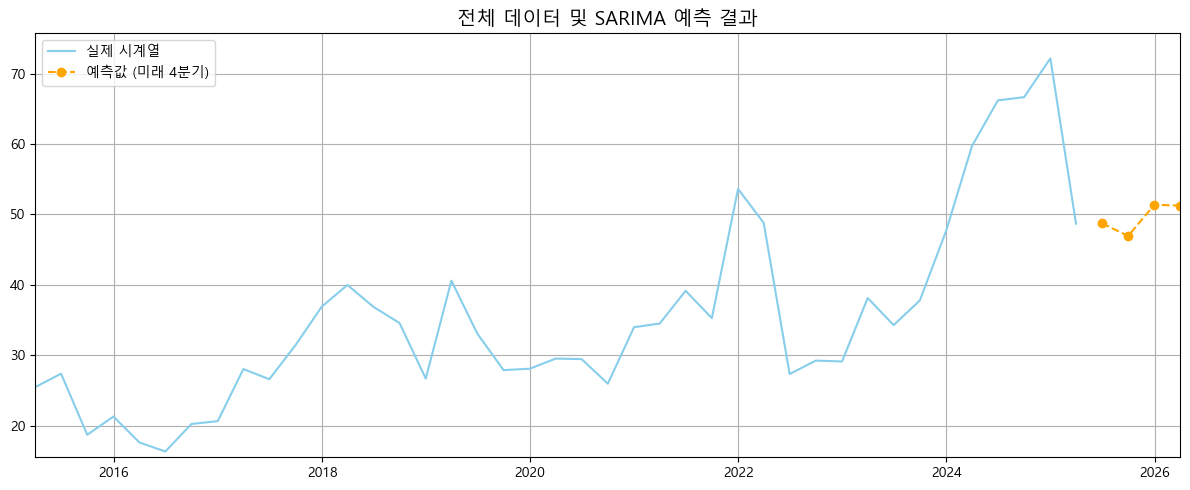


📈 미래 4분기 예측 결과:
2025-06-30    48.743129
2025-09-30    46.946294
2025-12-31    51.374276
2026-03-31    51.256358
Freq: Q-DEC, Name: predicted_mean, dtype: float64

📊 Ljung-Box Test (잔차 자기상관):
      lb_stat  lb_pvalue
4    3.216566   0.522259
8    4.420430   0.817340
12  10.267060   0.592544


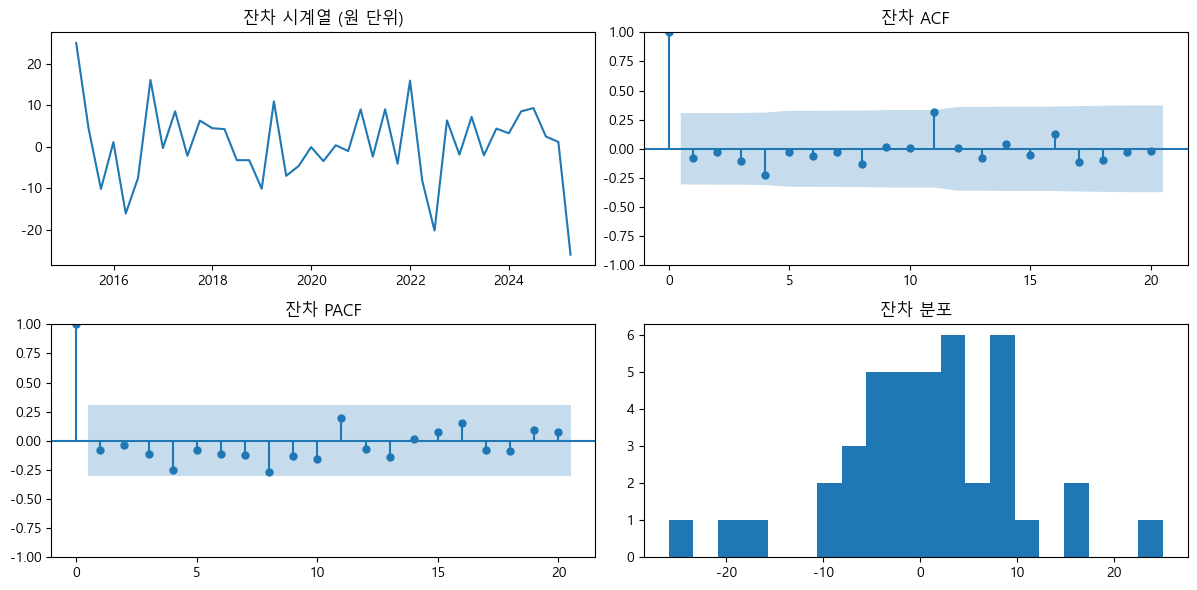

2025-06-30    48.743129
2025-09-30    46.946294
2025-12-31    51.374276
2026-03-31    51.256358
Freq: Q-DEC, Name: predicted_mean, dtype: float64

In [17]:
forecast_future_4q_with_sarima(merged_ratio_exog, value_col='endog_var', exog_col='exog_var', use_log= False, fixed_variable=0)